# animal001.ipynb — Animal Coin Index + Trend Following Research

This notebook is a multi-part research workflow for the Binance USD-M futures 4h animal/meme basket downloaded by `animal.py`.

Default basket:

```text
DOGEUSDT, POPCATUSDT, PENGUUSDT, 1000PEPEUSDT,
WIFUSDT, 1000SHIBUSDT, 1000BONKUSDT, UNIUSDT
```

Research goal:

> Build an animal/meme coin index and test whether systematic trend-following has evidence of edge.

We test:

1. Equal-weight vs inverse-volatility index construction.
2. Time-series momentum / trendiness using p-values.
3. Robert Carver-style multi-speed trend forecasts.
4. Long/flat and forecast-scaled trend strategies.
5. Robustness across costs, thresholds, years, and leave-one-coin-out tests.

This is research tooling, not financial advice.


## Part 0 — Research Protocol

### Hypotheses

| ID | Hypothesis | Evidence needed |
|---|---|---|
| H1 | Inverse-vol animal index is more stable than equal-weight | Lower volatility/drawdown without destroying returns |
| H2 | Animal index has trendiness | Past returns predict forward returns with reasonable p-values |
| H3 | Trend-following improves drawdown-adjusted returns vs buy-and-hold | Better risk metrics after costs |
| H4 | Multi-speed forecast is robust | Works across speeds/thresholds/costs |
| H5 | Result is not one-coin dependent | Leave-one-coin-out remains reasonable |

### P-value guardrail

```text
0.00001 < p < 0.05   candidate statistical evidence
p <= 0.00001         check leakage / repeated testing / overfit
p >= 0.05            weak evidence
```

Because 4h crypto returns are autocorrelated and fat-tailed, this notebook uses HAC/Newey-West-style tests where possible plus block-bootstrap p-values.


## Part 1 — Setup


In [35]:
# Optional install, run once if needed:
# !python -m pip install pandas numpy matplotlib scipy statsmodels

from __future__ import annotations
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False
    print("statsmodels not available; using scipy fallback for some tests.")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

%matplotlib inline


In [36]:
# =========================
# Config
# =========================

DATA_DIR = Path("animal_4h_csv")       # folder created by animal.py
OUT_DIR = Path("animal001_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

INTERVAL = "4h"
BARS_PER_DAY = 6
DAYS_PER_YEAR = 365
BARS_PER_YEAR = BARS_PER_DAY * DAYS_PER_YEAR

EXPECTED_SYMBOLS = [
    "DOGEUSDT",
    "POPCATUSDT",
    "PENGUUSDT",
    "1000PEPEUSDT",
    "WIFUSDT",
    "1000SHIBUSDT",
    "1000BONKUSDT",
]

FRIENDLY = {
    "DOGEUSDT": "DOGE",
    "POPCATUSDT": "POPCAT",
    "PENGUUSDT": "PENGU",
    "1000PEPEUSDT": "PEPE",
    "WIFUSDT": "WIF",
    "1000SHIBUSDT": "SHIB",
    "1000BONKUSDT": "BONK",
}

# Basket rules
ENTRY_DELAY_DAYS = 7
ENTRY_DELAY_BARS = ENTRY_DELAY_DAYS * BARS_PER_DAY
VOL_LOOKBACK_DAYS = 60
VOL_LOOKBACK_BARS = VOL_LOOKBACK_DAYS * BARS_PER_DAY
MIN_VOL_PERIODS = 30 * BARS_PER_DAY
MAX_COIN_WEIGHT = 0.25

# Strategy rules
TARGET_VOL = 0.50
MAX_GROSS_EXPOSURE = 1.0
COST_BPS = 5.0
TREND_SPEEDS = [(8, 32), (32, 128), (64, 256)]
FORECAST_CAP = 20.0
LONG_ENTRY_THRESHOLD = 5.0
LONG_EXIT_THRESHOLD = 0.0


## Part 2 — Load the CSVs from `animal.py`

Expected file examples:

```text
animal_4h_csv/DOGEUSDT_4h.csv
animal_4h_csv/POPCATUSDT_4h.csv
animal_4h_csv/1000PEPEUSDT_4h.csv
```


In [37]:
def load_symbol_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"symbol", "interval", "open_time", "open", "high", "low", "close", "volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns: {sorted(missing)}")
    if np.issubdtype(df["open_time"].dtype, np.number):
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    else:
        df["timestamp"] = pd.to_datetime(df["open_time"], utc=True, errors="coerce")
    numeric_cols = [
        "open","high","low","close","volume","quote_asset_volume",
        "number_of_trades","taker_buy_base_asset_volume","taker_buy_quote_asset_volume"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(subset=["timestamp","symbol","close"]).sort_values(["symbol","timestamp"])

def load_all(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob(f"*_{INTERVAL}.csv"))
    if not files:
        raise FileNotFoundError(f"No *_{INTERVAL}.csv files found in {data_dir.resolve()}. Run animal.py first.")
    raw = pd.concat([load_symbol_csv(p) for p in files], ignore_index=True)
    print("Loaded files:", len(files))
    print("Symbols:", sorted(raw["symbol"].unique()))
    missing = sorted(set(EXPECTED_SYMBOLS) - set(raw["symbol"].unique()))
    if missing:
        print("Missing expected symbols:", missing)
    return raw

raw = load_all(DATA_DIR)
display(raw.head())
display(raw.groupby("symbol").agg(start=("timestamp","min"), end=("timestamp","max"), rows=("timestamp","size")).sort_index())


Loaded files: 7
Symbols: ['1000BONKUSDT', '1000PEPEUSDT', '1000SHIBUSDT', 'DOGEUSDT', 'PENGUUSDT', 'POPCATUSDT', 'WIFUSDT']


,symbol,interval,open_time,open_time_iso,open,high,low,close,volume,close_time,close_time_iso,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore,source_file,timestamp
0,1000BONKUSDT,4h,1700654400000,2023-11-22T12:00:00+00:00,0.004780,0.004825,0.004076,0.004252,"4,318,438,243.000000",1700668799999,2023-11-22T15:59:59.999000+00:00,"18,705,698.625350",90747,"2,103,402,174.000000","9,113,060.707592",0,1000BONKUSDT-4h-2023-11-22.csv,2023-11-22 12:00:00+00:00
1,1000BONKUSDT,4h,1700668800000,2023-11-22T16:00:00+00:00,0.004254,0.004739,0.004150,0.004621,"5,626,812,586.000000",1700683199999,2023-11-22T19:59:59.999000+00:00,"25,012,244.585627",142060,"2,769,270,394.000000","12,322,399.085503",0,1000BONKUSDT-4h-2023-11-22.csv,2023-11-22 16:00:00+00:00
2,1000BONKUSDT,4h,1700683200000,2023-11-22T20:00:00+00:00,0.004619,0.004776,0.004395,0.004531,"2,755,747,104.000000",1700697599999,2023-11-22T23:59:59.999000+00:00,"12,649,884.287770",87908,"1,312,260,664.000000","6,031,875.334290",0,1000BONKUSDT-4h-2023-11-22.csv,2023-11-22 20:00:00+00:00
3,1000BONKUSDT,4h,1700697600000,2023-11-23T00:00:00+00:00,0.004531,0.004858,0.004180,0.004316,"3,843,368,724.000000",1700711999999,2023-11-23T03:59:59.999000+00:00,"17,348,131.452764",117070,"1,814,259,183.000000","8,203,745.494474",0,1000BONKUSDT-4h-2023-11-23.csv,2023-11-23 00:00:00+00:00
4,1000BONKUSDT,4h,1700712000000,2023-11-23T04:00:00+00:00,0.004315,0.004402,0.004153,0.004309,"2,661,094,714.000000",1700726399999,2023-11-23T07:59:59.999000+00:00,"11,387,505.360771",75738,"1,222,483,991.000000","5,235,938.058663",0,1000BONKUSDT-4h-2023-11-23.csv,2023-11-23 04:00:00+00:00


,start,end,rows
symbol,,,
1000BONKUSDT,2023-11-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,5319
1000PEPEUSDT,2023-05-05 16:00:00+00:00,2026-04-26 20:00:00+00:00,6524
1000SHIBUSDT,2021-05-10 16:00:00+00:00,2026-04-26 20:00:00+00:00,10874
DOGEUSDT,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700
PENGUUSDT,2024-12-17 16:00:00+00:00,2026-04-26 20:00:00+00:00,2972
POPCATUSDT,2024-08-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,3675
WIFUSDT,2024-01-18 12:00:00+00:00,2026-04-26 20:00:00+00:00,4977


## Part 3 — Data Quality EDA

Before building an index, check duplicates, missing 4h bars, bad OHLC, zero volume, and listing-date bias.


In [38]:
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for symbol, g in df.groupby("symbol"):
        g = g.sort_values("timestamp").copy()
        start, end = g["timestamp"].min(), g["timestamp"].max()
        expected = pd.date_range(start=start, end=end, freq=INTERVAL, tz="UTC")
        actual = pd.DatetimeIndex(g["timestamp"])
        bad_ohlc = (
            (g["high"] < g["low"]) |
            (g["open"] > g["high"]) | (g["open"] < g["low"]) |
            (g["close"] > g["high"]) | (g["close"] < g["low"]) |
            (g["volume"] < 0)
        )
        rows.append({
            "symbol": symbol,
            "friendly": FRIENDLY.get(symbol, symbol),
            "start": start,
            "end": end,
            "rows": len(g),
            "expected_4h_bars": len(expected),
            "missing_4h_bars": len(expected.difference(actual)),
            "duplicate_bars": int(g.duplicated("timestamp").sum()),
            "zero_volume_bars": int((g["volume"].fillna(0) <= 0).sum()),
            "bad_ohlc_bars": int(bad_ohlc.sum()),
            "entry_date_after_delay": start + pd.Timedelta(days=ENTRY_DELAY_DAYS),
        })
    return pd.DataFrame(rows).sort_values("start")

quality = data_quality_report(raw)
quality.to_csv(OUT_DIR / "data_quality_report.csv", index=False)
display(quality)


,symbol,friendly,start,end,rows,expected_4h_bars,missing_4h_bars,duplicate_bars,zero_volume_bars,bad_ohlc_bars,entry_date_after_delay
3,DOGEUSDT,DOGE,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,12700,0,0,0,0,2020-07-17 08:00:00+00:00
2,1000SHIBUSDT,SHIB,2021-05-10 16:00:00+00:00,2026-04-26 20:00:00+00:00,10874,10874,0,0,0,0,2021-05-17 16:00:00+00:00
1,1000PEPEUSDT,PEPE,2023-05-05 16:00:00+00:00,2026-04-26 20:00:00+00:00,6524,6524,0,0,0,0,2023-05-12 16:00:00+00:00
0,1000BONKUSDT,BONK,2023-11-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,5319,5319,0,0,0,0,2023-11-29 12:00:00+00:00
6,WIFUSDT,WIF,2024-01-18 12:00:00+00:00,2026-04-26 20:00:00+00:00,4977,4977,0,0,0,0,2024-01-25 12:00:00+00:00
5,POPCATUSDT,POPCAT,2024-08-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,3675,3675,0,0,0,0,2024-08-29 12:00:00+00:00
4,PENGUUSDT,PENGU,2024-12-17 16:00:00+00:00,2026-04-26 20:00:00+00:00,2972,2972,0,0,0,0,2024-12-24 16:00:00+00:00


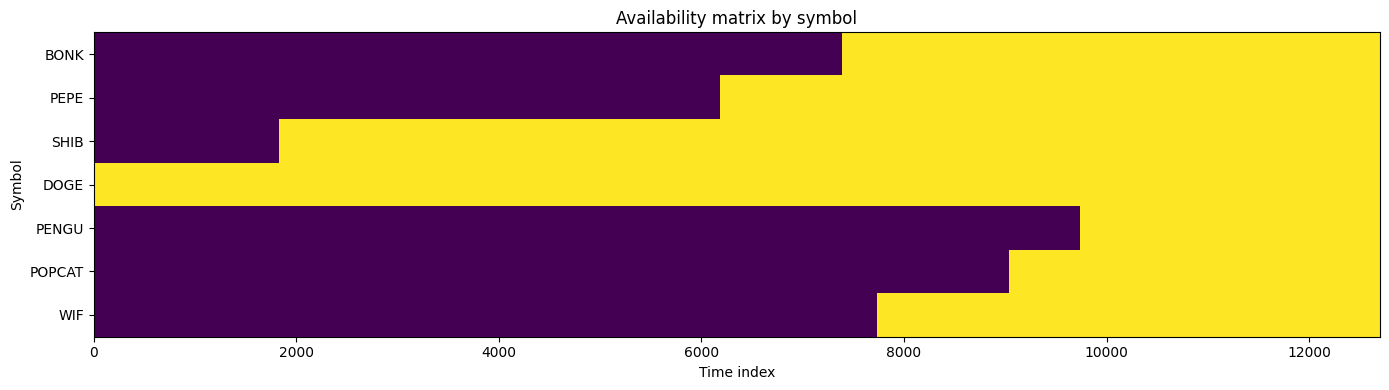

In [39]:
close_panel_raw = raw.pivot_table(index="timestamp", columns="symbol", values="close", aggfunc="last").sort_index()
availability = close_panel_raw.notna().astype(int)

fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(availability.T.values, aspect="auto", interpolation="nearest")
ax.set_title("Availability matrix by symbol")
ax.set_yticks(range(len(availability.columns)))
ax.set_yticklabels([FRIENDLY.get(s, s) for s in availability.columns])
ax.set_xlabel("Time index")
ax.set_ylabel("Symbol")
plt.tight_layout()
plt.savefig(OUT_DIR / "availability_matrix.png", dpi=150)
plt.show()


## Part 4 — Build Price, Return, Volume Panels


In [40]:
def make_panel(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    if value_col not in df.columns:
        return pd.DataFrame(index=sorted(df["timestamp"].unique()))
    return df.pivot_table(index="timestamp", columns="symbol", values=value_col, aggfunc="last").sort_index()

close_panel = make_panel(raw, "close")
volume_panel = make_panel(raw, "volume")
quote_volume_panel = make_panel(raw, "quote_asset_volume")
trade_count_panel = make_panel(raw, "number_of_trades")

simple_returns = close_panel.pct_change(fill_method=None).dropna(how="all")
log_returns = np.log(close_panel / close_panel.shift(1)).dropna(how="all")

close_panel.to_csv(OUT_DIR / "close_panel.csv")
simple_returns.to_csv(OUT_DIR / "simple_returns.csv")
log_returns.to_csv(OUT_DIR / "log_returns.csv")

print("close_panel:", close_panel.shape)
print("simple_returns:", simple_returns.shape)
display(close_panel.tail())


close_panel: (12700, 7)
simple_returns: (12699, 7)


symbol,1000BONKUSDT,1000PEPEUSDT,1000SHIBUSDT,DOGEUSDT,PENGUUSDT,POPCATUSDT,WIFUSDT
timestamp,,,,,,,
2026-04-26 04:00:00+00:00,0.006303,0.003894,0.006208,0.098520,0.008762,0.061420,0.179400
2026-04-26 08:00:00+00:00,0.006347,0.003934,0.006224,0.098980,0.008958,0.061970,0.180100
2026-04-26 12:00:00+00:00,0.006304,0.003923,0.006199,0.098980,0.008760,0.061680,0.178400
2026-04-26 16:00:00+00:00,0.006295,0.003908,0.006201,0.099130,0.009002,0.061700,0.178400
2026-04-26 20:00:00+00:00,0.006292,0.003894,0.006207,0.099160,0.008943,0.062220,0.177800


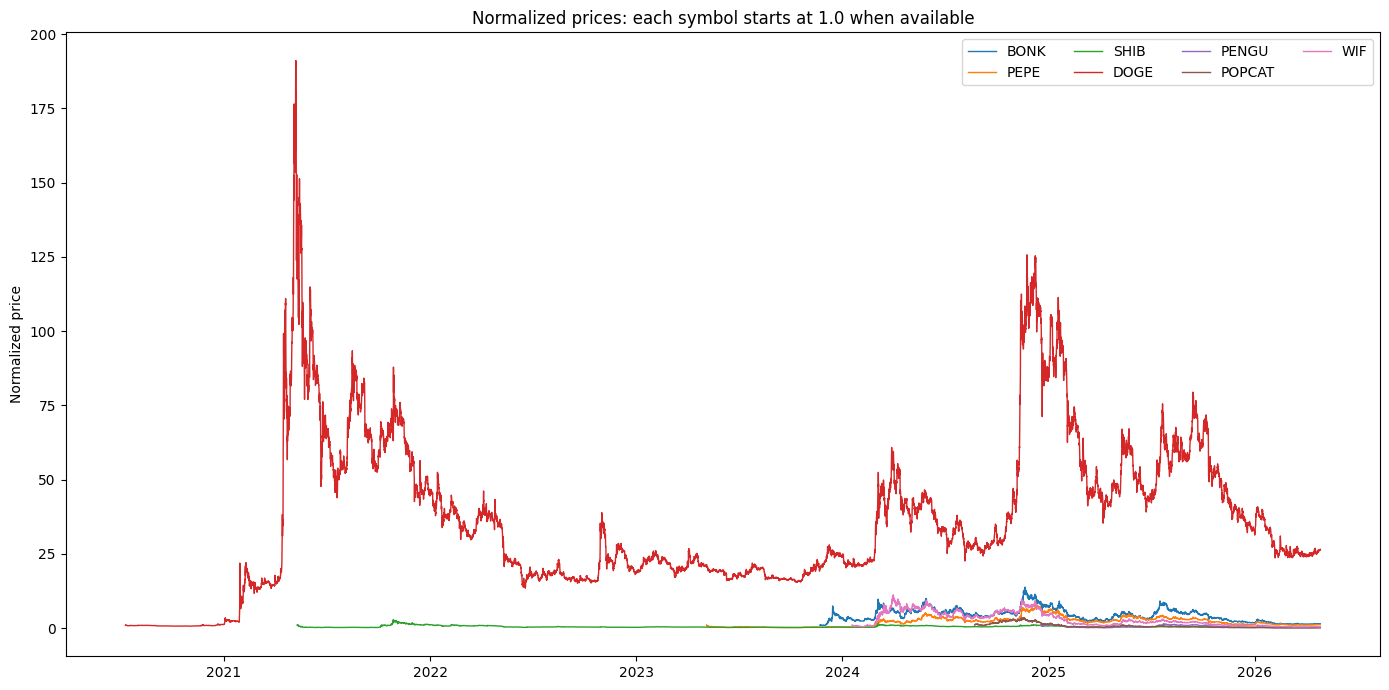

In [41]:
norm_prices = close_panel / close_panel.apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)

fig, ax = plt.subplots(figsize=(14, 7))
for col in norm_prices.columns:
    ax.plot(norm_prices.index, norm_prices[col], label=FRIENDLY.get(col, col), linewidth=1)
ax.set_title("Normalized prices: each symbol starts at 1.0 when available")
ax.set_ylabel("Normalized price")
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig(OUT_DIR / "normalized_prices.png", dpi=150)
plt.show()


## Part 5 — Basket / Index Construction

We build two point-in-time indexes:

1. **Equal-weight**
2. **Inverse-volatility weighted**

Rules:

- Coin is eligible only after `ENTRY_DELAY_DAYS`.
- Inverse-vol uses rolling 60-day volatility shifted by one bar.
- Single coin weight is capped at `MAX_COIN_WEIGHT`.


In [42]:
def cap_and_normalize_row(row: pd.Series, cap: float = 0.25) -> pd.Series:
    row = row.astype(float).where(np.isfinite(row), 0.0)
    row[row < 0] = 0.0
    if row.sum() <= 0:
        return row * np.nan
    w = row / row.sum()
    for _ in range(len(w) + 2):
        over = w > cap
        if not over.any():
            break
        under = ~over
        w[over] = cap
        remaining = 1.0 - w[over].sum()
        if remaining <= 0 or under.sum() == 0:
            w[under] = 0.0
            break
        if w[under].sum() <= 0:
            w[under] = remaining / under.sum()
        else:
            w[under] = w[under] / w[under].sum() * remaining
    return w / w.sum() if w.sum() > 0 else w

def eligibility_matrix(returns: pd.DataFrame, entry_delay_bars: int) -> pd.DataFrame:
    obs_count = returns.notna().cumsum()
    return (obs_count > entry_delay_bars) & returns.notna()

def equal_weight_matrix(returns: pd.DataFrame, eligible: pd.DataFrame) -> pd.DataFrame:
    raw = eligible.astype(float)
    return raw.div(raw.sum(axis=1).replace(0, np.nan), axis=0)

def inverse_vol_weight_matrix(returns: pd.DataFrame, eligible: pd.DataFrame) -> pd.DataFrame:
    vol = returns.shift(1).rolling(VOL_LOOKBACK_BARS, min_periods=MIN_VOL_PERIODS).std() * math.sqrt(BARS_PER_YEAR)
    inv_vol = (1.0 / vol.replace(0, np.nan)).where(eligible)
    raw = inv_vol.div(inv_vol.sum(axis=1), axis=0)
    return raw.apply(lambda r: cap_and_normalize_row(r, cap=MAX_COIN_WEIGHT), axis=1)

def portfolio_returns(asset_returns: pd.DataFrame, weights: pd.DataFrame) -> pd.Series:
    r, w = asset_returns.align(weights, join="inner", axis=0)
    return (r * w).sum(axis=1, min_count=1)

def equity_from_returns(returns: pd.Series, start_value: float = 100.0) -> pd.Series:
    return start_value * (1.0 + returns.fillna(0.0)).cumprod()

eligible = eligibility_matrix(simple_returns, ENTRY_DELAY_BARS)
ew_weights = equal_weight_matrix(simple_returns, eligible)
iv_weights = inverse_vol_weight_matrix(simple_returns, eligible)

ew_index_returns = portfolio_returns(simple_returns, ew_weights).rename("animal_equal_weight")
iv_index_returns = portfolio_returns(simple_returns, iv_weights).rename("animal_inverse_vol")

index_returns = pd.concat([ew_index_returns, iv_index_returns], axis=1).dropna(how="all")
index_equity = index_returns.apply(equity_from_returns)

ew_weights.to_csv(OUT_DIR / "equal_weight_matrix.csv")
iv_weights.to_csv(OUT_DIR / "inverse_vol_weight_matrix.csv")
index_returns.to_csv(OUT_DIR / "index_returns.csv")
index_equity.to_csv(OUT_DIR / "index_equity.csv")

display(index_equity.tail())


,animal_equal_weight,animal_inverse_vol
timestamp,,
2026-04-26 04:00:00+00:00,"12,382.958827",548.492870
2026-04-26 08:00:00+00:00,"12,488.748983",552.854691
2026-04-26 12:00:00+00:00,"12,399.566040",549.268434
2026-04-26 16:00:00+00:00,"12,443.390007",550.907903
2026-04-26 20:00:00+00:00,"12,435.558211",550.663778


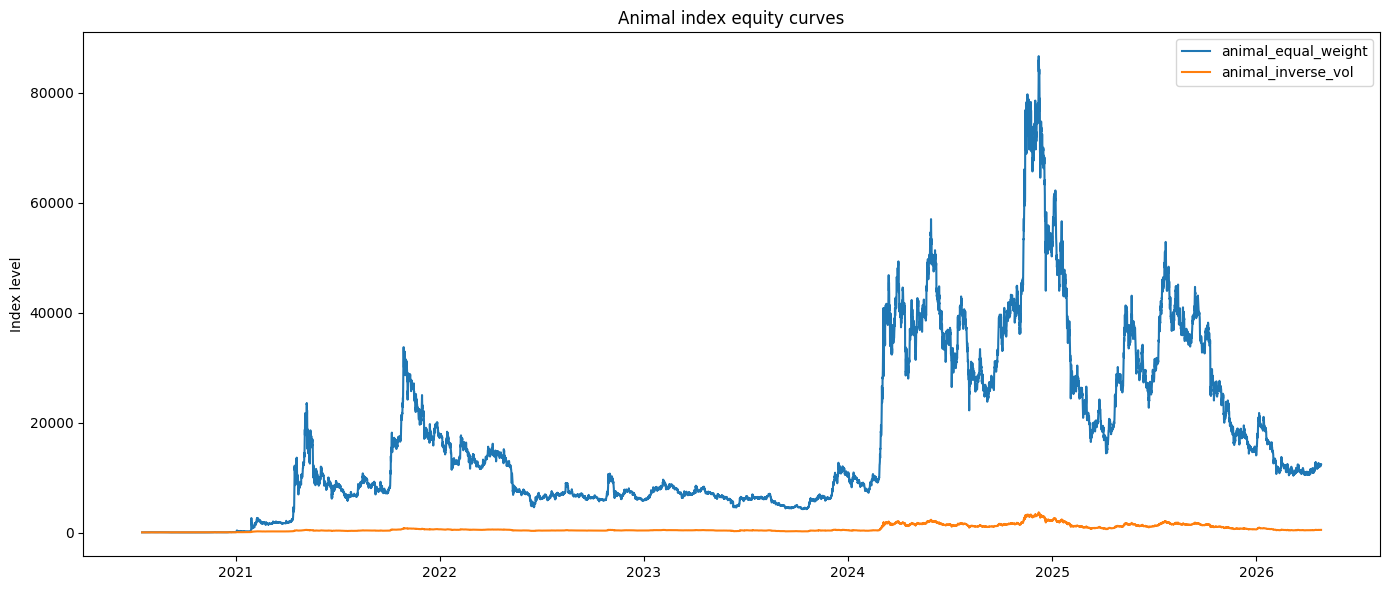

,latest_inverse_vol_weight,friendly
symbol,,
DOGEUSDT,0.182006,DOGE
1000SHIBUSDT,0.176369,SHIB
1000BONKUSDT,0.136613,BONK
1000PEPEUSDT,0.131437,PEPE
POPCATUSDT,0.128786,POPCAT
WIFUSDT,0.126249,WIF
PENGUUSDT,0.118539,PENGU


In [43]:
fig, ax = plt.subplots(figsize=(14, 6))
for col in index_equity.columns:
    ax.plot(index_equity.index, index_equity[col], label=col)
ax.set_title("Animal index equity curves")
ax.set_ylabel("Index level")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "index_equity_curves.png", dpi=150)
plt.show()

latest_weights = iv_weights.dropna(how="all").tail(1).T
latest_weights.columns = ["latest_inverse_vol_weight"]
latest_weights["friendly"] = latest_weights.index.map(lambda x: FRIENDLY.get(x, x))
display(latest_weights.sort_values("latest_inverse_vol_weight", ascending=False))


## Part 6 — Risk Metrics and Drawdowns


In [44]:
def max_drawdown(equity: pd.Series) -> float:
    e = equity.dropna()
    if e.empty:
        return np.nan
    return float((e / e.cummax() - 1.0).min())

def drawdown_series(equity: pd.Series) -> pd.Series:
    e = equity.dropna()
    return e / e.cummax() - 1.0

def perf_stats(returns: pd.Series, name: str) -> dict:
    r = returns.dropna()
    if r.empty:
        return {"name": name}
    eq = equity_from_returns(r)
    years = len(r) / BARS_PER_YEAR
    total_return = eq.iloc[-1] / eq.iloc[0] - 1
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan
    ann_vol = r.std(ddof=1) * math.sqrt(BARS_PER_YEAR)
    ann_mean = r.mean() * BARS_PER_YEAR
    mdd = max_drawdown(eq)
    return {
        "name": name,
        "start": r.index.min(),
        "end": r.index.max(),
        "bars": len(r),
        "years": years,
        "total_return": total_return,
        "cagr": cagr,
        "ann_mean": ann_mean,
        "ann_vol": ann_vol,
        "sharpe_like": ann_mean / ann_vol if ann_vol > 0 else np.nan,
        "max_drawdown": mdd,
        "calmar": cagr / abs(mdd) if mdd < 0 else np.nan,
        "hit_rate": (r > 0).mean(),
        "best_bar": r.max(),
        "worst_bar": r.min(),
    }

index_metrics = pd.DataFrame([
    perf_stats(index_returns["animal_equal_weight"], "animal_equal_weight"),
    perf_stats(index_returns["animal_inverse_vol"], "animal_inverse_vol"),
])
index_metrics.to_csv(OUT_DIR / "index_performance_metrics.csv", index=False)
display(index_metrics)


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar
0,animal_equal_weight,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,123.314622,1.303607,1.738120,1.408280,1.234215,-0.879445,1.482307,0.499960,1.253744,-0.372638
1,animal_inverse_vol,2020-08-09 12:00:00+00:00,2026-04-26 20:00:00+00:00,12519,5.716438,4.530722,0.348770,0.654477,0.846757,0.772923,-0.874985,0.398601,0.499720,0.313436,-0.208116


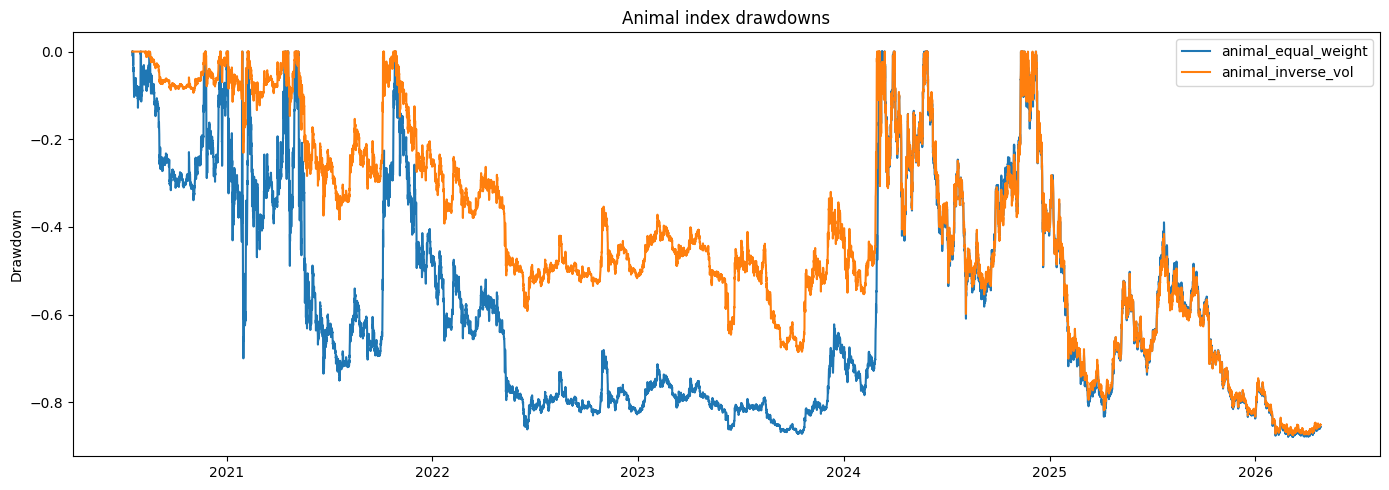

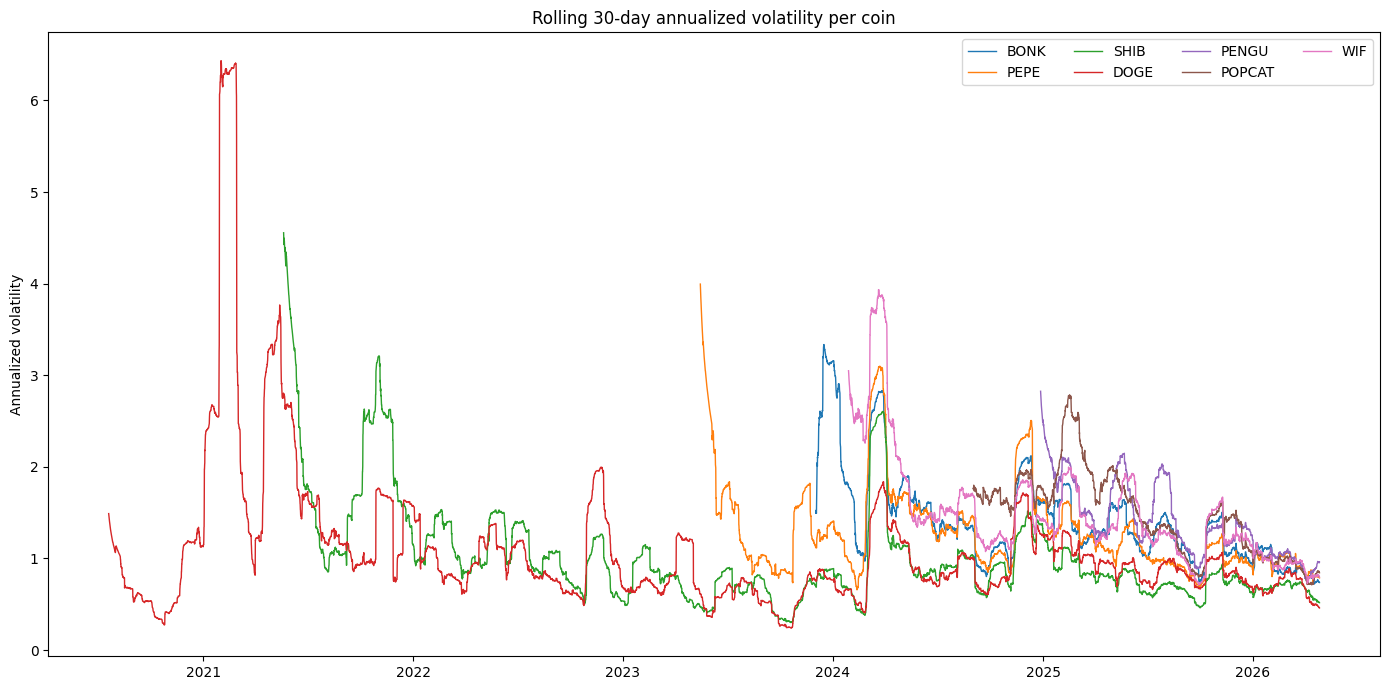

In [45]:
fig, ax = plt.subplots(figsize=(14, 5))
for col in index_equity.columns:
    ax.plot(drawdown_series(index_equity[col]).index, drawdown_series(index_equity[col]), label=col)
ax.set_title("Animal index drawdowns")
ax.set_ylabel("Drawdown")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "index_drawdowns.png", dpi=150)
plt.show()

rolling_vol = simple_returns.rolling(30 * BARS_PER_DAY, min_periods=10 * BARS_PER_DAY).std() * math.sqrt(BARS_PER_YEAR)
fig, ax = plt.subplots(figsize=(14, 7))
for col in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[col], label=FRIENDLY.get(col, col), linewidth=1)
ax.set_title("Rolling 30-day annualized volatility per coin")
ax.set_ylabel("Annualized volatility")
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig(OUT_DIR / "rolling_30d_vol_per_coin.png", dpi=150)
plt.show()


## Part 7 — Correlation EDA


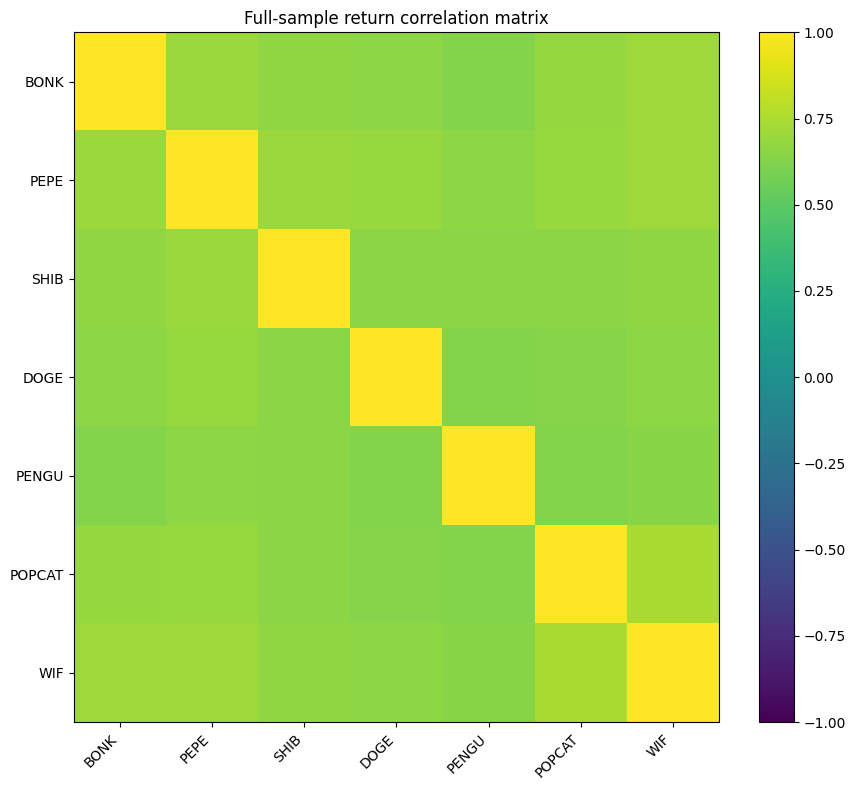

symbol,BONK,PEPE,SHIB,DOGE,PENGU,POPCAT,WIF
symbol,,,,,,,
BONK,1.000000,0.700584,0.669957,0.663776,0.627034,0.685559,0.705283
PEPE,0.700584,1.000000,0.702834,0.688976,0.659333,0.690276,0.704288
SHIB,0.669957,0.702834,1.000000,0.654896,0.652382,0.655814,0.666631
DOGE,0.663776,0.688976,0.654896,1.000000,0.627771,0.634695,0.657992
PENGU,0.627034,0.659333,0.652382,0.627771,1.000000,0.625663,0.643228
POPCAT,0.685559,0.690276,0.655814,0.634695,0.625663,1.000000,0.742363
WIF,0.705283,0.704288,0.666631,0.657992,0.643228,0.742363,1.000000


In [46]:
corr = simple_returns.corr()
corr_friendly = corr.rename(index=FRIENDLY, columns=FRIENDLY)
corr_friendly.to_csv(OUT_DIR / "correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_friendly.values, aspect="auto", vmin=-1, vmax=1)
ax.set_title("Full-sample return correlation matrix")
ax.set_xticks(range(len(corr_friendly.columns)))
ax.set_xticklabels(corr_friendly.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_friendly.index)))
ax.set_yticklabels(corr_friendly.index)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "correlation_heatmap.png", dpi=150)
plt.show()
display(corr_friendly)


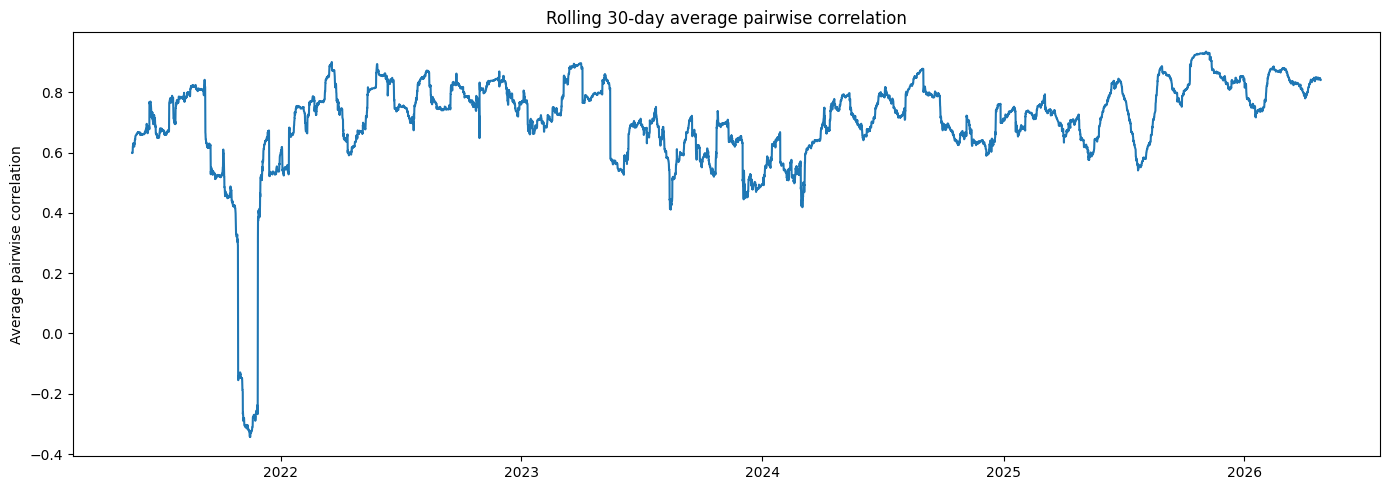

In [47]:
def avg_pairwise_corr(c: pd.DataFrame) -> float:
    vals = c.values
    n = vals.shape[0]
    if n < 2:
        return np.nan
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    return np.nanmean(vals[mask])

rolling_avg_corr = (
    simple_returns
    .rolling(30 * BARS_PER_DAY, min_periods=10 * BARS_PER_DAY)
    .corr()
    .groupby(level=0)
    .apply(avg_pairwise_corr)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_avg_corr.index, rolling_avg_corr)
ax.set_title("Rolling 30-day average pairwise correlation")
ax.set_ylabel("Average pairwise correlation")
plt.tight_layout()
plt.savefig(OUT_DIR / "rolling_avg_pairwise_corr.png", dpi=150)
plt.show()


## Part 8 — Trendiness EDA + P-Value Tests

We test:

```text
past N-day index return -> future M-day index return
```

Using:

- HAC OLS slope p-values
- Spearman rank correlation p-values
- bucket plots
- autocorrelation


In [48]:
def significance_label(p: float) -> str:
    if pd.isna(p): return "NA"
    if p <= 1e-5: return "too_small_check_leakage"
    if p < 0.05: return "candidate_evidence"
    return "weak_evidence"

def hac_ols_test(y: pd.Series, x: pd.Series, maxlags: int = 12) -> dict:
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    if len(df) < 50:
        return {"n": len(df), "coef": np.nan, "t": np.nan, "p": np.nan, "r2": np.nan}
    if HAS_STATSMODELS:
        X = sm.add_constant(df["x"])
        model = sm.OLS(df["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
        return {"n": len(df), "coef": model.params.get("x", np.nan), "t": model.tvalues.get("x", np.nan), "p": model.pvalues.get("x", np.nan), "r2": model.rsquared}
    slope, intercept, r, p, se = stats.linregress(df["x"], df["y"])
    return {"n": len(df), "coef": slope, "t": slope / se if se > 0 else np.nan, "p": p, "r2": r**2}

def trend_predictability_tests(index_return: pd.Series, name: str) -> pd.DataFrame:
    log_r = np.log1p(index_return.dropna())
    rows = []
    for lookback_days in [3, 7, 14, 30, 60]:
        past = log_r.rolling(lookback_days * BARS_PER_DAY).sum().shift(1)
        for horizon_days in [1, 3, 7, 14]:
            h = horizon_days * BARS_PER_DAY
            future = log_r.shift(-1).rolling(h).sum().shift(-(h - 1))
            ols = hac_ols_test(future, past, maxlags=max(h, 1))
            df = pd.concat([future.rename("future"), past.rename("past")], axis=1).dropna()
            if len(df) >= 30:
                sr, sp = stats.spearmanr(df["past"], df["future"])
            else:
                sr, sp = np.nan, np.nan
            rows.append({
                "series": name,
                "lookback_days": lookback_days,
                "horizon_days": horizon_days,
                "n": ols["n"],
                "ols_coef": ols["coef"],
                "ols_t": ols["t"],
                "ols_p": ols["p"],
                "ols_p_label": significance_label(ols["p"]),
                "ols_r2": ols["r2"],
                "spearman_r": sr,
                "spearman_p": sp,
                "spearman_p_label": significance_label(sp),
            })
    return pd.DataFrame(rows)

trend_tests = pd.concat([
    trend_predictability_tests(index_returns["animal_equal_weight"], "animal_equal_weight"),
    trend_predictability_tests(index_returns["animal_inverse_vol"], "animal_inverse_vol"),
], ignore_index=True)
trend_tests.to_csv(OUT_DIR / "trend_predictability_tests.csv", index=False)
display(trend_tests.sort_values(["ols_p", "series"]).head(20))


,series,lookback_days,horizon_days,n,ols_coef,ols_t,ols_p,ols_p_label,ols_r2,spearman_r,spearman_p,spearman_p_label
21,animal_inverse_vol,3,3,12483,0.113731,2.158127,0.030918,candidate_evidence,0.012933,0.005857,0.512866,weak_evidence
24,animal_inverse_vol,7,1,12471,0.024104,2.146364,0.031844,candidate_evidence,0.004860,-0.002557,0.775222,weak_evidence
20,animal_inverse_vol,3,1,12495,0.037638,2.140907,0.032282,candidate_evidence,0.004433,-0.009752,0.275689,weak_evidence
3,animal_equal_weight,3,14,12555,0.152750,2.131214,0.033071,candidate_evidence,0.004203,0.036787,0.000037,candidate_evidence
33,animal_inverse_vol,30,3,12321,0.022614,2.044479,0.040906,candidate_evidence,0.006740,0.042302,0.000003,too_small_check_leakage
32,animal_inverse_vol,30,1,12333,0.007899,1.931497,0.053422,weak_evidence,0.002573,0.013285,0.140132,weak_evidence
25,animal_inverse_vol,7,3,12459,0.056914,1.827180,0.067673,weak_evidence,0.008659,0.013773,0.124230,weak_evidence
13,animal_equal_weight,30,3,12459,0.021876,1.776147,0.075709,weak_evidence,0.006224,0.033146,0.000215,candidate_evidence
28,animal_inverse_vol,14,1,12429,0.011335,1.769501,0.076810,weak_evidence,0.002306,0.006944,0.438873,weak_evidence
1,animal_equal_weight,3,3,12621,0.087475,1.691673,0.090708,weak_evidence,0.007654,-0.000402,0.963937,weak_evidence


,past_mean,future_mean,future_median,future_count
bucket,,,,
0,-0.205150,0.002960,0.000270,2484
1,-0.066102,-0.008861,-0.005410,2483
2,-0.010591,0.000303,-0.001677,2483
3,0.051576,0.008004,0.000350,2483
4,0.286238,0.009948,-0.001487,2484


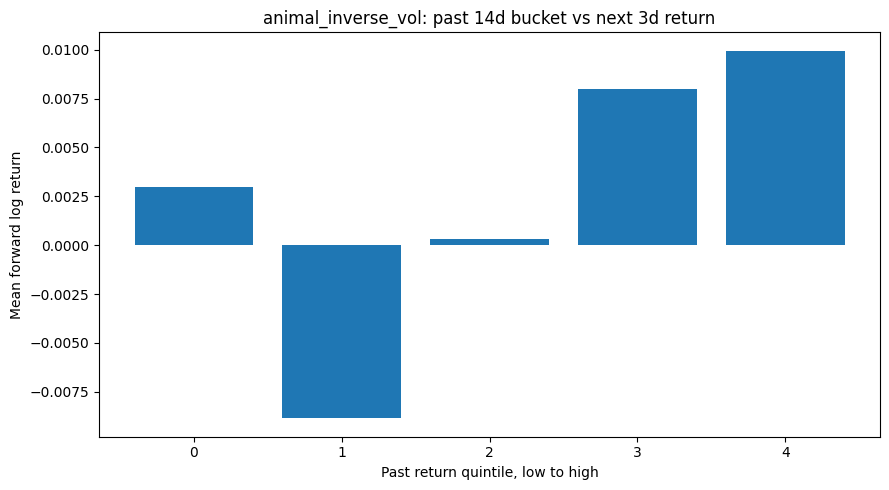

In [49]:
# Bucket plot: past 14-day return vs next 3-day return on inverse-vol index.
series_name = "animal_inverse_vol"
r = index_returns[series_name].dropna()
log_r = np.log1p(r)

lookback_days = 14
horizon_days = 3
past = log_r.rolling(lookback_days * BARS_PER_DAY).sum().shift(1)
future = log_r.shift(-1).rolling(horizon_days * BARS_PER_DAY).sum().shift(-(horizon_days * BARS_PER_DAY - 1))

bucket_df = pd.concat([past.rename("past"), future.rename("future")], axis=1).dropna()
bucket_df["bucket"] = pd.qcut(bucket_df["past"], q=5, labels=False, duplicates="drop")
bucket_stats = bucket_df.groupby("bucket").agg(
    past_mean=("past", "mean"),
    future_mean=("future", "mean"),
    future_median=("future", "median"),
    future_count=("future", "size"),
)
display(bucket_stats)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(bucket_stats.index.astype(str), bucket_stats["future_mean"])
ax.set_title(f"{series_name}: past {lookback_days}d bucket vs next {horizon_days}d return")
ax.set_xlabel("Past return quintile, low to high")
ax.set_ylabel("Mean forward log return")
plt.tight_layout()
plt.savefig(OUT_DIR / "past_return_bucket_vs_future_return.png", dpi=150)
plt.show()


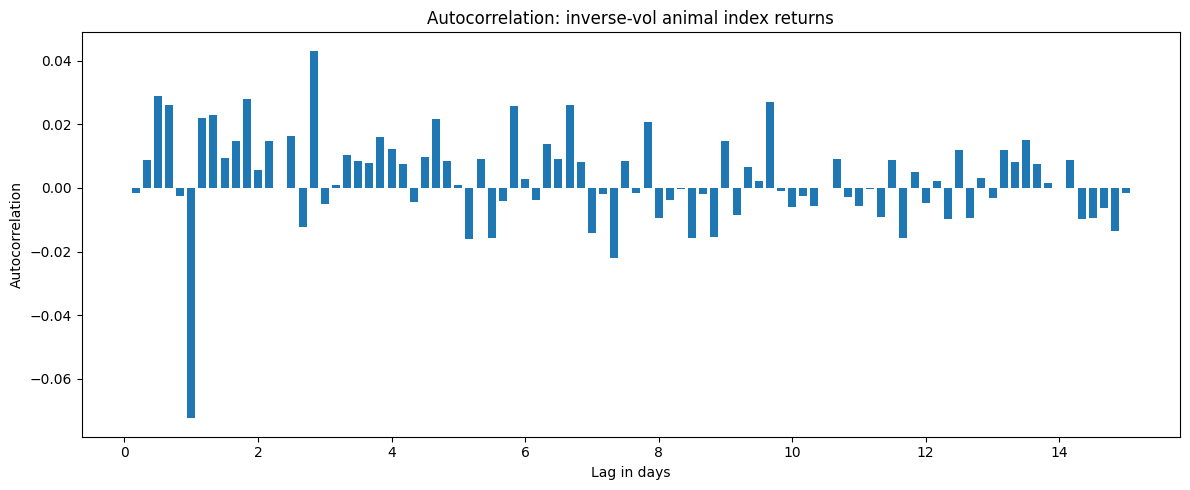

In [50]:
def autocorr_table(r: pd.Series, max_lag_bars: int = 90) -> pd.DataFrame:
    r = r.dropna()
    return pd.DataFrame([{"lag_bars": lag, "lag_days": lag / BARS_PER_DAY, "autocorr": r.autocorr(lag)} for lag in range(1, max_lag_bars + 1)])

ac = autocorr_table(index_returns["animal_inverse_vol"])
ac.to_csv(OUT_DIR / "autocorrelation_inverse_vol_index.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ac["lag_days"], ac["autocorr"], width=0.12)
ax.set_title("Autocorrelation: inverse-vol animal index returns")
ax.set_xlabel("Lag in days")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig(OUT_DIR / "autocorrelation_inverse_vol_index.png", dpi=150)
plt.show()


## Part 9 — Carver-Style Trend Forecast

We use multi-speed EWMA crossovers:

```text
16/64, 32/128, 64/256
```

Forecast is volatility-adjusted and clipped to `[-20, +20]`.


In [51]:
def make_index_price(index_return: pd.Series, start_value: float = 100.0) -> pd.Series:
    return equity_from_returns(index_return.dropna(), start_value)

def trend_forecast(price: pd.Series, fast_span: int, slow_span: int, vol_lookback: int, cap: float = 20.0) -> pd.Series:
    price = price.dropna()
    returns = price.pct_change()
    fast = price.ewm(span=fast_span, adjust=False).mean()
    slow = price.ewm(span=slow_span, adjust=False).mean()
    raw_trend = fast / slow - 1.0
    vol_per_bar = returns.shift(1).rolling(vol_lookback, min_periods=max(20, vol_lookback // 3)).std()
    z = raw_trend / vol_per_bar.replace(0, np.nan)
    return (z * 2.5).clip(-cap, cap).rename(f"ewma_{fast_span}_{slow_span}")

base_index_name = "animal_inverse_vol"
base_index_returns = index_returns[base_index_name].dropna()
base_index_price = make_index_price(base_index_returns)

forecast_df = pd.concat([trend_forecast(base_index_price, f, s, VOL_LOOKBACK_BARS, FORECAST_CAP) for f, s in TREND_SPEEDS], axis=1)
forecast_df["composite_forecast"] = forecast_df.mean(axis=1)
forecast_df.to_csv(OUT_DIR / "trend_forecasts.csv")
display(forecast_df.tail())


,ewma_8_32,ewma_32_128,ewma_64_256,composite_forecast
timestamp,,,,
2026-04-26 04:00:00+00:00,0.516961,5.236447,5.021018,3.591475
2026-04-26 08:00:00+00:00,0.951372,5.304554,5.098343,3.784756
2026-04-26 12:00:00+00:00,1.085999,5.322186,5.154765,3.854317
2026-04-26 16:00:00+00:00,1.272341,5.462109,5.322959,4.019136
2026-04-26 20:00:00+00:00,1.371697,5.517296,5.414747,4.101246


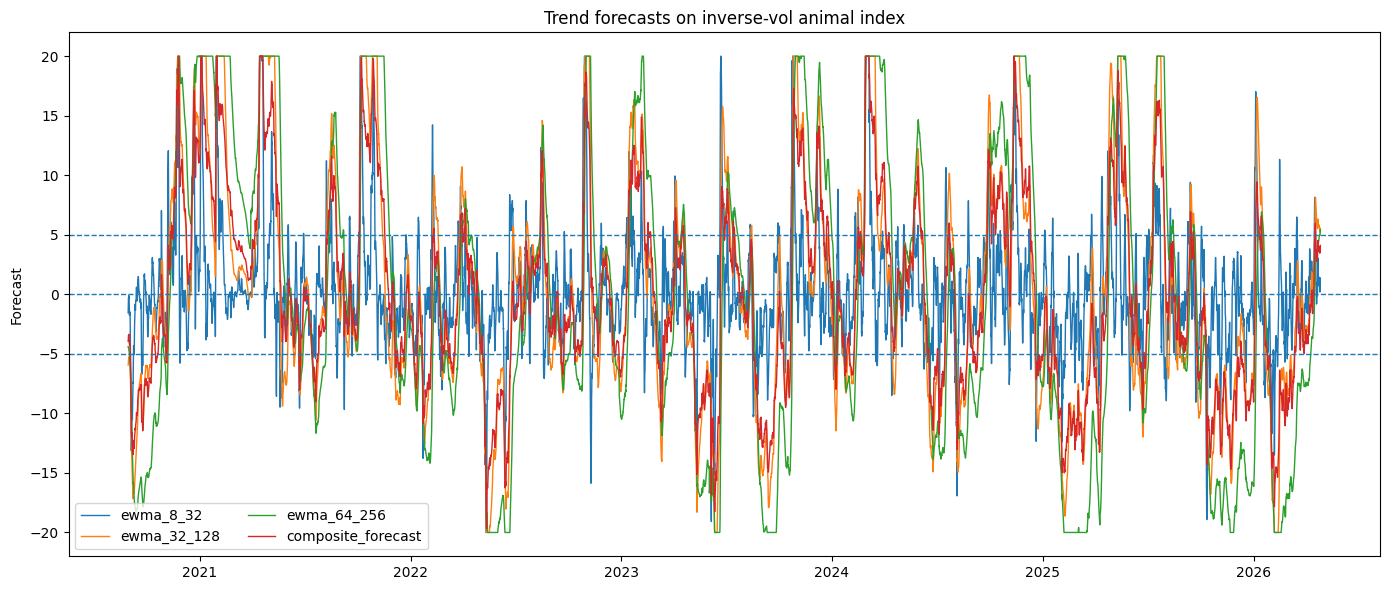

In [52]:
fig, ax = plt.subplots(figsize=(14, 6))
for col in forecast_df.columns:
    ax.plot(forecast_df.index, forecast_df[col], label=col, linewidth=1)
ax.axhline(LONG_ENTRY_THRESHOLD, linestyle="--", linewidth=1)
ax.axhline(LONG_EXIT_THRESHOLD, linestyle="--", linewidth=1)
ax.axhline(-LONG_ENTRY_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Trend forecasts on inverse-vol animal index")
ax.set_ylabel("Forecast")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / "trend_forecasts.png", dpi=150)
plt.show()


## Part 10 — Backtest

We test:

1. **Long/flat** trend strategy.
2. **Forecast-scaled long-only** trend strategy.

We include transaction costs from exposure turnover:

```text
cost = cost_bps / 10000 * abs(exposure change)
```


In [53]:
def vol_target_exposure(returns: pd.Series, target_vol: float, max_gross: float) -> pd.Series:
    ann_vol = returns.shift(1).rolling(VOL_LOOKBACK_BARS, min_periods=max(20, VOL_LOOKBACK_BARS // 3)).std() * math.sqrt(BARS_PER_YEAR)
    scale = target_vol / ann_vol.replace(0, np.nan)
    return scale.clip(upper=max_gross)

def backtest_long_flat(returns: pd.Series, forecast: pd.Series, entry: float, exit_: float, target_vol: float, cost_bps: float) -> pd.DataFrame:
    df = pd.concat([returns.rename("index_return"), forecast.rename("forecast")], axis=1).dropna()
    state, in_market = [], False
    for f in df["forecast"]:
        if not in_market and f > entry:
            in_market = True
        elif in_market and f < exit_:
            in_market = False
        state.append(1.0 if in_market else 0.0)
    signal = pd.Series(state, index=df.index, name="signal")
    scale = vol_target_exposure(df["index_return"], target_vol, MAX_GROSS_EXPOSURE)
    exposure = (signal * scale).shift(1).fillna(0.0).clip(0, MAX_GROSS_EXPOSURE)
    turnover = exposure.diff().abs().fillna(exposure.abs())
    cost = turnover * (cost_bps / 10000)
    strategy_return = exposure * df["index_return"] - cost
    out = pd.DataFrame({"index_return": df["index_return"], "forecast": df["forecast"], "signal": signal, "exposure": exposure, "turnover": turnover, "cost": cost, "strategy_return": strategy_return})
    out["strategy_equity"] = equity_from_returns(out["strategy_return"])
    out["buyhold_equity"] = equity_from_returns(out["index_return"])
    return out

def backtest_forecast_scaled(returns: pd.Series, forecast: pd.Series, target_vol: float, cost_bps: float, long_only: bool = True) -> pd.DataFrame:
    df = pd.concat([returns.rename("index_return"), forecast.rename("forecast")], axis=1).dropna()
    forecast_unit = (df["forecast"] / FORECAST_CAP).clip(-1, 1)
    if long_only:
        forecast_unit = forecast_unit.clip(lower=0)
    scale = vol_target_exposure(df["index_return"], target_vol, MAX_GROSS_EXPOSURE)
    exposure = (forecast_unit * scale).shift(1).fillna(0.0)
    exposure = exposure.clip(0, MAX_GROSS_EXPOSURE) if long_only else exposure.clip(-MAX_GROSS_EXPOSURE, MAX_GROSS_EXPOSURE)
    turnover = exposure.diff().abs().fillna(exposure.abs())
    cost = turnover * (cost_bps / 10000)
    strategy_return = exposure * df["index_return"] - cost
    out = pd.DataFrame({"index_return": df["index_return"], "forecast": df["forecast"], "forecast_unit": forecast_unit, "exposure": exposure, "turnover": turnover, "cost": cost, "strategy_return": strategy_return})
    out["strategy_equity"] = equity_from_returns(out["strategy_return"])
    out["buyhold_equity"] = equity_from_returns(out["index_return"])
    return out

composite = forecast_df["composite_forecast"]
bt_long_flat = backtest_long_flat(base_index_returns, composite, LONG_ENTRY_THRESHOLD, LONG_EXIT_THRESHOLD, TARGET_VOL, COST_BPS)
bt_scaled = backtest_forecast_scaled(base_index_returns, composite, TARGET_VOL, COST_BPS, long_only=True)

bt_long_flat.to_csv(OUT_DIR / "backtest_long_flat.csv")
bt_scaled.to_csv(OUT_DIR / "backtest_forecast_scaled_long_only.csv")
display(bt_long_flat.tail())


,index_return,forecast,signal,exposure,turnover,cost,strategy_return,strategy_equity,buyhold_equity
timestamp,,,,,,,,,
2026-04-26 04:00:00+00:00,0.013425,3.591475,1.000000,0.682079,0.000238,0.000000,0.009157,"1,015.496304",557.043211
2026-04-26 08:00:00+00:00,0.007952,3.784756,1.000000,0.683002,0.000923,0.000000,0.005431,"1,021.011490",561.473028
2026-04-26 12:00:00+00:00,-0.006487,3.854317,1.000000,0.682342,0.000660,0.000000,-0.004427,"1,016.491936",557.830865
2026-04-26 16:00:00+00:00,0.002985,4.019136,1.000000,0.682849,0.000507,0.000000,0.002038,"1,018.563476",559.495891
2026-04-26 20:00:00+00:00,-0.000443,4.101246,1.000000,0.696920,0.014071,0.000007,-0.000316,"1,018.241750",559.247961


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar
0,buyhold_inverse_vol_index,2020-08-29 16:00:00+00:00,2026-04-26 20:00:00+00:00,12398,5.661187,4.590770,0.355297,0.663503,0.850766,0.779889,-0.874985,0.406060,0.500000,0.313436,-0.208116
1,trend_long_flat,2020-08-29 16:00:00+00:00,2026-04-26 20:00:00+00:00,12398,5.661187,9.182417,0.506705,0.471704,0.355665,1.326260,-0.381315,1.328834,0.185191,0.251252,-0.071356
2,trend_forecast_scaled_long_only,2020-08-29 16:00:00+00:00,2026-04-26 20:00:00+00:00,12398,5.661187,5.076918,0.375406,0.345716,0.235361,1.468877,-0.198340,1.892742,0.229392,0.199740,-0.065374


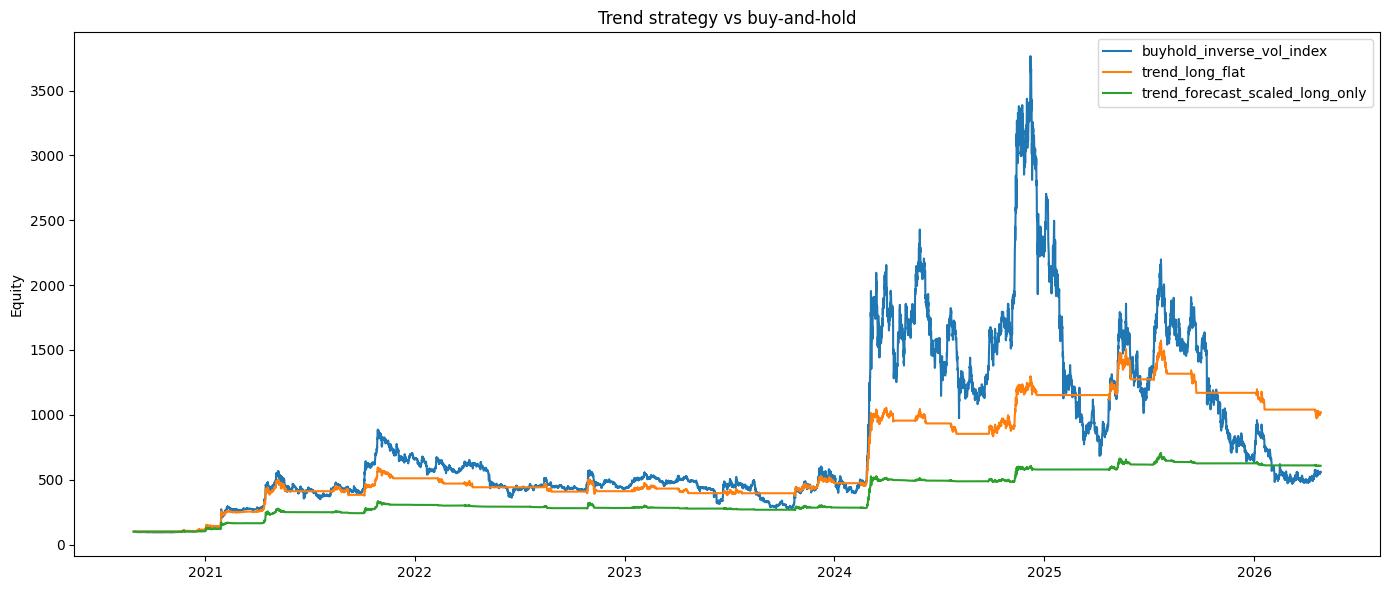

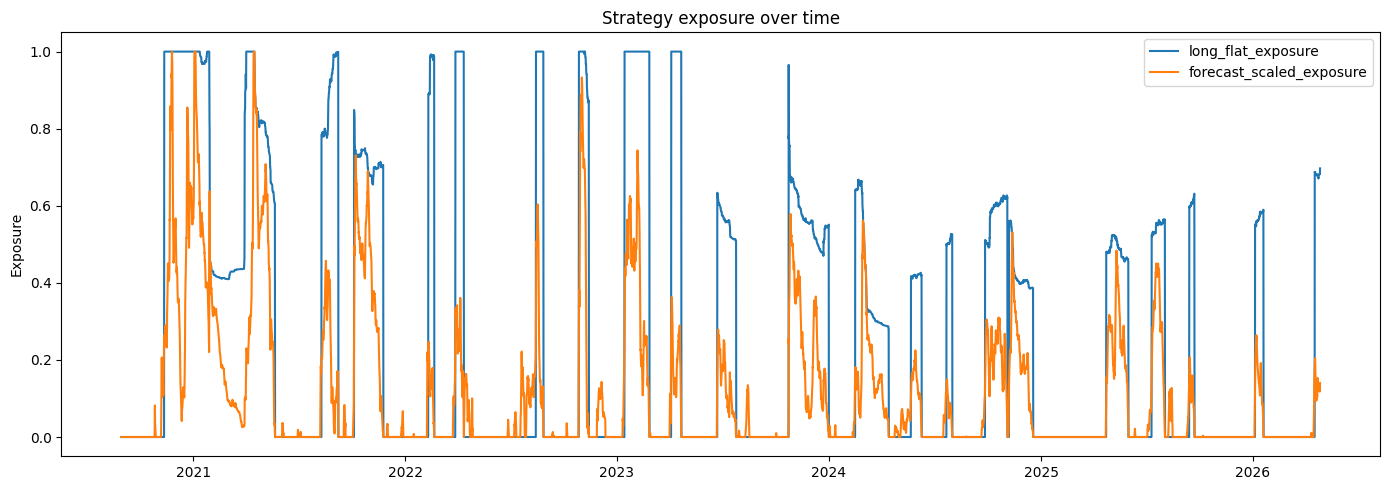

In [54]:
strategy_metrics = pd.DataFrame([
    perf_stats(bt_long_flat["index_return"], "buyhold_inverse_vol_index"),
    perf_stats(bt_long_flat["strategy_return"], "trend_long_flat"),
    perf_stats(bt_scaled["strategy_return"], "trend_forecast_scaled_long_only"),
])
strategy_metrics.to_csv(OUT_DIR / "strategy_performance_metrics.csv", index=False)
display(strategy_metrics)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_long_flat.index, bt_long_flat["buyhold_equity"], label="buyhold_inverse_vol_index")
ax.plot(bt_long_flat.index, bt_long_flat["strategy_equity"], label="trend_long_flat")
ax.plot(bt_scaled.index, bt_scaled["strategy_equity"], label="trend_forecast_scaled_long_only")
ax.set_title("Trend strategy vs buy-and-hold")
ax.set_ylabel("Equity")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "trend_strategy_vs_buyhold.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bt_long_flat.index, bt_long_flat["exposure"], label="long_flat_exposure")
ax.plot(bt_scaled.index, bt_scaled["exposure"], label="forecast_scaled_exposure")
ax.set_title("Strategy exposure over time")
ax.set_ylabel("Exposure")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "strategy_exposure.png", dpi=150)
plt.show()


## Part 11 — Strategy P-Value Tests

We test whether strategy excess return over buy-and-hold is positive.

Tests:

1. HAC mean test.
2. Block-bootstrap mean p-value.


In [55]:
def hac_mean_test(x: pd.Series, maxlags: int = 42) -> dict:
    x = x.dropna()
    if len(x) < 50:
        return {"n": len(x), "mean": np.nan, "t": np.nan, "p_greater": np.nan}
    if HAS_STATSMODELS:
        X = np.ones((len(x), 1))
        model = sm.OLS(x.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
        mean = model.params[0]
        tval = model.tvalues[0]
        p_greater = 1.0 - stats.t.cdf(tval, df=max(len(x) - 1, 1))
        return {"n": len(x), "mean": mean, "t": tval, "p_greater": p_greater}
    tval, p_two = stats.ttest_1samp(x.values, popmean=0.0)
    return {"n": len(x), "mean": x.mean(), "t": tval, "p_greater": p_two / 2 if tval > 0 else 1 - p_two / 2}

def block_bootstrap_mean_pvalue(x: pd.Series, block_size: int = 42, n_boot: int = 1000, random_state: int = 7) -> dict:
    x = x.dropna().values.astype(float)
    n = len(x)
    if n < block_size * 3:
        return {"n": n, "observed_mean": np.nan, "bootstrap_p": np.nan}
    rng = np.random.default_rng(random_state)
    observed = x.mean()
    centered = x - observed
    starts = np.arange(0, n - block_size + 1)
    boot_means = []
    for _ in range(n_boot):
        pieces = []
        while sum(len(p) for p in pieces) < n:
            start = rng.choice(starts)
            pieces.append(centered[start:start + block_size])
        boot_means.append(np.concatenate(pieces)[:n].mean())
    boot_means = np.array(boot_means)
    return {"n": n, "observed_mean": observed, "bootstrap_p": np.mean(boot_means >= observed)}

def strategy_pvalue_report(bt: pd.DataFrame, name: str) -> dict:
    excess = bt["strategy_return"] - bt["index_return"]
    hac = hac_mean_test(excess, maxlags=14 * BARS_PER_DAY)
    boot = block_bootstrap_mean_pvalue(excess, block_size=7 * BARS_PER_DAY, n_boot=1000)
    return {
        "strategy": name,
        "mean_excess_per_bar": hac["mean"],
        "ann_excess_simple": hac["mean"] * BARS_PER_YEAR if pd.notna(hac["mean"]) else np.nan,
        "hac_t": hac["t"],
        "hac_p_greater": hac["p_greater"],
        "hac_p_label": significance_label(hac["p_greater"]),
        "bootstrap_p_greater": boot["bootstrap_p"],
        "bootstrap_p_label": significance_label(boot["bootstrap_p"]),
        "n": hac["n"],
    }

pvalue_results = pd.DataFrame([
    strategy_pvalue_report(bt_long_flat, "trend_long_flat"),
    strategy_pvalue_report(bt_scaled, "trend_forecast_scaled_long_only"),
])
pvalue_results.to_csv(OUT_DIR / "strategy_pvalue_results.csv", index=False)
display(pvalue_results)


,strategy,mean_excess_per_bar,ann_excess_simple,hac_t,hac_p_greater,hac_p_label,bootstrap_p_greater,bootstrap_p_label,n
0,trend_long_flat,-0.000088,-0.191799,-0.669720,0.748476,weak_evidence,0.768000,weak_evidence,12398
1,trend_forecast_scaled_long_only,-0.000145,-0.317787,-0.972743,0.834650,weak_evidence,0.843000,weak_evidence,12398


## Part 12 — Robustness Grid: Thresholds and Costs


,threshold,cost_bps,cagr,ann_vol,sharpe_like,max_drawdown,total_return,avg_exposure,turnover_ann
5,2.500000,0,0.567687,0.366748,1.405258,-0.393573,11.746739,0.280219,7.673978
6,2.500000,2,0.565292,0.366731,1.401137,-0.396285,11.636906,0.280219,7.673978
7,2.500000,5,0.561706,0.366707,1.394952,-0.400331,11.473901,0.280219,7.673978
8,2.500000,10,0.555747,0.366669,1.384630,-0.407016,11.206813,0.280219,7.673978
0,0.000000,0,0.588800,0.387825,1.383156,-0.428806,12.749631,0.312023,14.837116
15,7.500000,0,0.513439,0.341313,1.380462,-0.292683,9.442772,0.207189,4.462309
16,7.500000,2,0.512085,0.341322,1.377814,-0.293763,9.389975,0.207189,4.462309
1,0.000000,2,0.584091,0.387828,1.375493,-0.433828,12.520510,0.312023,14.837116
17,7.500000,5,0.510055,0.341335,1.373840,-0.295381,9.311267,0.207189,4.462309
18,7.500000,10,0.506678,0.341358,1.367211,-0.298069,9.181379,0.207189,4.462309


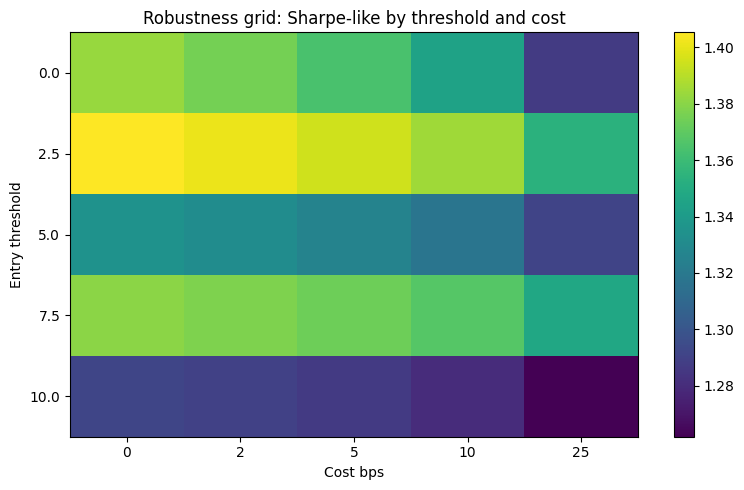

In [56]:
def run_threshold_cost_grid(returns: pd.Series, forecast: pd.Series, thresholds: list[float], cost_bps_list: list[float]) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        for cost_bps in cost_bps_list:
            bt = backtest_long_flat(returns, forecast, threshold, 0.0, TARGET_VOL, cost_bps)
            s = perf_stats(bt["strategy_return"], f"thresh_{threshold}_cost_{cost_bps}")
            rows.append({
                "threshold": threshold,
                "cost_bps": cost_bps,
                "cagr": s.get("cagr", np.nan),
                "ann_vol": s.get("ann_vol", np.nan),
                "sharpe_like": s.get("sharpe_like", np.nan),
                "max_drawdown": s.get("max_drawdown", np.nan),
                "total_return": s.get("total_return", np.nan),
                "avg_exposure": bt["exposure"].mean(),
                "turnover_ann": bt["turnover"].mean() * BARS_PER_YEAR,
            })
    return pd.DataFrame(rows)

grid = run_threshold_cost_grid(
    base_index_returns,
    composite,
    thresholds=[0, 2.5, 5, 7.5, 10],
    cost_bps_list=[0, 2, 5, 10, 25],
)
grid.to_csv(OUT_DIR / "threshold_cost_robustness_grid.csv", index=False)
display(grid.sort_values("sharpe_like", ascending=False).head(20))

pivot = grid.pivot(index="threshold", columns="cost_bps", values="sharpe_like")
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Robustness grid: Sharpe-like by threshold and cost")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Cost bps")
ax.set_ylabel("Entry threshold")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "threshold_cost_robustness_heatmap.png", dpi=150)
plt.show()


## Part 13 — Year-by-Year Breakdown


,buyhold_inverse_vol_index,trend_long_flat,trend_forecast_scaled_long_only
timestamp,,,
2020,0.119833,0.156187,0.028868
2021,4.899094,3.418980,1.973931
2022,-0.343936,-0.194608,-0.078683
2023,0.137001,0.156096,0.013294
2024,3.646770,1.422853,1.025788
2025,-0.725111,0.014939,0.081298
2026,-0.111515,-0.129572,-0.028799


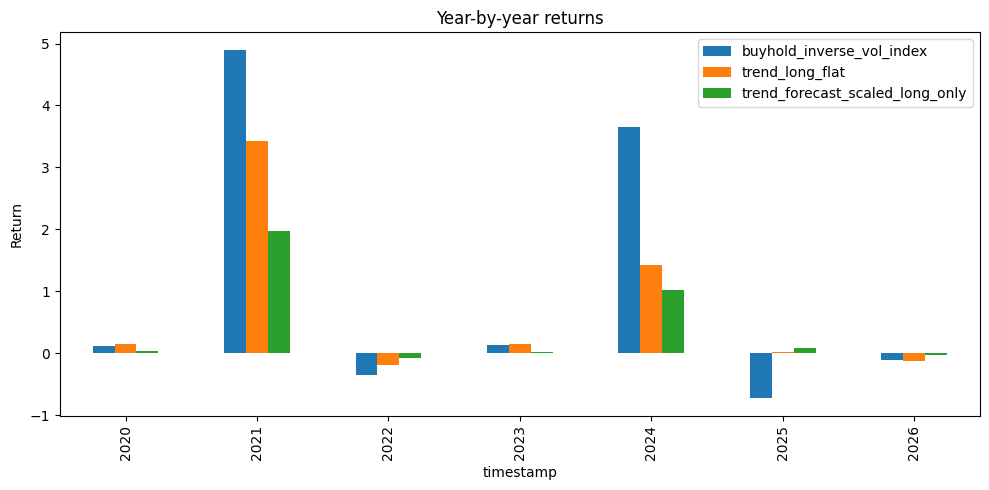

In [57]:
def yearly_returns_from_series(returns: pd.Series) -> pd.Series:
    r = returns.dropna()
    return (1 + r).groupby(r.index.year).prod() - 1 if not r.empty else pd.Series(dtype=float)

yearly = pd.DataFrame({
    "buyhold_inverse_vol_index": yearly_returns_from_series(bt_long_flat["index_return"]),
    "trend_long_flat": yearly_returns_from_series(bt_long_flat["strategy_return"]),
    "trend_forecast_scaled_long_only": yearly_returns_from_series(bt_scaled["strategy_return"]),
})
yearly.to_csv(OUT_DIR / "yearly_returns.csv")
display(yearly)

fig, ax = plt.subplots(figsize=(10, 5))
yearly.plot(kind="bar", ax=ax)
ax.set_title("Year-by-year returns")
ax.set_ylabel("Return")
plt.tight_layout()
plt.savefig(OUT_DIR / "yearly_returns.png", dpi=150)
plt.show()


## Part 14 — Leave-One-Coin-Out Test


In [58]:
def build_equal_index_for_symbols(asset_returns: pd.DataFrame, symbols: list[str]) -> pd.Series:
    sub = asset_returns[symbols]
    sub_eligible = eligibility_matrix(sub, ENTRY_DELAY_BARS)
    sub_weights = equal_weight_matrix(sub, sub_eligible)
    return portfolio_returns(sub, sub_weights)

def run_trend_on_index_returns(r: pd.Series) -> dict:
    price = make_index_price(r.dropna())
    f = pd.concat([trend_forecast(price, fast, slow, VOL_LOOKBACK_BARS, FORECAST_CAP) for fast, slow in TREND_SPEEDS], axis=1).mean(axis=1)
    bt = backtest_long_flat(r.dropna(), f, LONG_ENTRY_THRESHOLD, LONG_EXIT_THRESHOLD, TARGET_VOL, COST_BPS)
    return perf_stats(bt["strategy_return"], "trend_long_flat")

loo_rows = []
symbols = list(simple_returns.columns)
for excluded in symbols:
    keep = [s for s in symbols if s != excluded]
    if len(keep) < 2:
        continue
    s = run_trend_on_index_returns(build_equal_index_for_symbols(simple_returns, keep))
    s["excluded_symbol"] = excluded
    s["excluded_friendly"] = FRIENDLY.get(excluded, excluded)
    loo_rows.append(s)

loo = pd.DataFrame(loo_rows)
loo.to_csv(OUT_DIR / "leave_one_coin_out_trend_results.csv", index=False)
display(loo[["excluded_friendly", "cagr", "ann_vol", "sharpe_like", "max_drawdown", "calmar", "bars"]].sort_values("sharpe_like"))


,excluded_friendly,cagr,ann_vol,sharpe_like,max_drawdown,calmar,bars
3,DOGE,0.218970,0.316108,0.782582,-0.456616,0.479550,10710
4,PENGU,0.626818,0.387348,1.444986,-0.406244,1.542961,12536
0,BONK,0.629499,0.386823,1.450653,-0.391354,1.608514,12536
2,SHIB,0.662048,0.394007,1.480334,-0.382509,1.730806,12536
6,WIF,0.664516,0.389130,1.499017,-0.391354,1.697990,12536
5,POPCAT,0.669191,0.390602,1.502004,-0.411029,1.628089,12536
1,PEPE,0.696485,0.389811,1.546023,-0.366559,1.900062,12536


## Part 15 — Research Summary

Run this after the notebook finishes.

A real candidate should pass most of these:

- Data quality is clean.
- Listing-date bias is handled.
- Trend predictability has supporting evidence.
- Strategy improves drawdown-adjusted performance vs buy-and-hold.
- Results survive costs.
- Results survive leave-one-coin-out.
- Results are not only from one calendar year.


In [59]:
def print_research_summary():
    print("=" * 80)
    print("ANIMAL001 RESEARCH SUMMARY")
    print("=" * 80)
    print("\n1) Data quality")
    display(quality)
    print("\n2) Index metrics")
    display(index_metrics)
    print("\n3) Best trend predictability tests")
    display(trend_tests.sort_values("ols_p").head(10))
    print("\n4) Strategy metrics")
    display(strategy_metrics)
    print("\n5) Strategy p-values")
    display(pvalue_results)
    print("\n6) Robustness grid best rows")
    display(grid.sort_values("sharpe_like", ascending=False).head(10))
    print("\n7) Yearly returns")
    display(yearly)
    print("\n8) Leave-one-coin-out")
    display(loo[["excluded_friendly", "cagr", "ann_vol", "sharpe_like", "max_drawdown", "calmar", "bars"]].sort_values("sharpe_like"))
    print("\nInterpretation:")
    print("- If p-values are weak and bucket plots are flat, do not proceed.")
    print("- If costs kill performance, reject current implementation.")
    print("- If one coin drives results, research component-level strategies.")
    print("- If results survive robustness, build animal002 with funding, BTC/SOL benchmarks, and walk-forward testing.")

print_research_summary()


ANIMAL001 RESEARCH SUMMARY

1) Data quality


,symbol,friendly,start,end,rows,expected_4h_bars,missing_4h_bars,duplicate_bars,zero_volume_bars,bad_ohlc_bars,entry_date_after_delay
3,DOGEUSDT,DOGE,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,12700,0,0,0,0,2020-07-17 08:00:00+00:00
2,1000SHIBUSDT,SHIB,2021-05-10 16:00:00+00:00,2026-04-26 20:00:00+00:00,10874,10874,0,0,0,0,2021-05-17 16:00:00+00:00
1,1000PEPEUSDT,PEPE,2023-05-05 16:00:00+00:00,2026-04-26 20:00:00+00:00,6524,6524,0,0,0,0,2023-05-12 16:00:00+00:00
0,1000BONKUSDT,BONK,2023-11-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,5319,5319,0,0,0,0,2023-11-29 12:00:00+00:00
6,WIFUSDT,WIF,2024-01-18 12:00:00+00:00,2026-04-26 20:00:00+00:00,4977,4977,0,0,0,0,2024-01-25 12:00:00+00:00
5,POPCATUSDT,POPCAT,2024-08-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,3675,3675,0,0,0,0,2024-08-29 12:00:00+00:00
4,PENGUUSDT,PENGU,2024-12-17 16:00:00+00:00,2026-04-26 20:00:00+00:00,2972,2972,0,0,0,0,2024-12-24 16:00:00+00:00



2) Index metrics


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar
0,animal_equal_weight,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,123.314622,1.303607,1.738120,1.408280,1.234215,-0.879445,1.482307,0.499960,1.253744,-0.372638
1,animal_inverse_vol,2020-08-09 12:00:00+00:00,2026-04-26 20:00:00+00:00,12519,5.716438,4.530722,0.348770,0.654477,0.846757,0.772923,-0.874985,0.398601,0.499720,0.313436,-0.208116



3) Best trend predictability tests


...


7) Yearly returns


,buyhold_inverse_vol_index,trend_long_flat,trend_forecast_scaled_long_only
timestamp,,,
2020,0.119833,0.156187,0.028868
2021,4.899094,3.418980,1.973931
2022,-0.343936,-0.194608,-0.078683
2023,0.137001,0.156096,0.013294
2024,3.646770,1.422853,1.025788
2025,-0.725111,0.014939,0.081298
2026,-0.111515,-0.129572,-0.028799



8) Leave-one-coin-out


,excluded_friendly,cagr,ann_vol,sharpe_like,max_drawdown,calmar,bars
3,DOGE,0.218970,0.316108,0.782582,-0.456616,0.479550,10710
4,PENGU,0.626818,0.387348,1.444986,-0.406244,1.542961,12536
0,BONK,0.629499,0.386823,1.450653,-0.391354,1.608514,12536
2,SHIB,0.662048,0.394007,1.480334,-0.382509,1.730806,12536
6,WIF,0.664516,0.389130,1.499017,-0.391354,1.697990,12536
5,POPCAT,0.669191,0.390602,1.502004,-0.411029,1.628089,12536
1,PEPE,0.696485,0.389811,1.546023,-0.366559,1.900062,12536



Interpretation:
- If p-values are weak and bucket plots are flat, do not proceed.
- If costs kill performance, reject current implementation.
- If one coin drives results, research component-level strategies.
- If results survive robustness, build animal002 with funding, BTC/SOL benchmarks, and walk-forward testing.


## Part 16 — Next Notebook Ideas

Recommended next step:

```text
animal002_benchmarks_funding_walkforward.ipynb
```

Add:

1. BTCUSDT, ETHUSDT, SOLUSDT benchmarks.
2. Funding rates for USD-M futures.
3. Open interest and mark-price klines.
4. Per-coin execution costs and basket turnover costs.
5. Walk-forward train/test splits.
6. Component-level trend following.
7. Parameter stability plots.
